# TIM - TP12 : Opérations sur des images avec Python

In [2]:
%matplotlib inline

# Librairies Matplotlib, NumPy et OpenCV
import matplotlib.pyplot as plt
import numpy as np
import cv2 #OpenCV

# Librairies supplémentaires pour certaines parties du TP
from sklearn.cluster import MiniBatchKMeans

Et définissez le chemin d'accès à la base d'images (utilisée ultérieurement)

In [3]:
# A changer si le dossier ne se situe pas à cet endroit
path_base = 'Base_images/'

## Ex. 1 : Lecture et visualisation des images avec OpenCV

OpenCV est capable de lire et de décoder les fichiers images BMP, JPEG, PNG, WEBP, PBM, PGM, PPM, SR, RAS et TIFF. Comme expliqué précédemment, une image est représentée sous forme d'une matrice. Avant de traiter une image avec OpenCV, il faut la lire et décoder son format afin de la transformer en une matrice de valeurs.

**1.**

Lisez l'image *lena_gray.tif*, dans le dossier *base_images*, et stockez-la dans la variable *img*.

In [4]:
img = cv2.imread(path_base+'lena_gray.tif',-1) 
# Le 2ème argument désigne le type de couleur de l'image 
#   0 pour la charger en niveaux de gris
#   1 pour la charger en couleur
#   -1 pour la charger telle qu'elle est
print(path_base+'lena_gray.tif')

Base_images/lena_gray.tif


Affichez l'image.

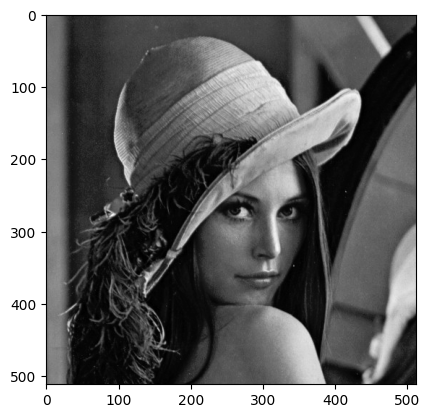

In [5]:
plt.imshow(img,'gray')

Récuperez quelques infos utiles de notre image.

In [6]:
rows,cols = img.shape
img_dtype = img.dtype
print(rows, cols)
print(img_dtype)

512 512
uint8


---
**2.**

Chaque élement de la matrice correspond donc à un pixel de l'image. Dans le cas de notre matrice *img* en niveaux de gris, chaque pixel à la position *(i,j)* contient donc une seule valeur **_I_** *(i,j)*, qui est le niveau de gris au point *(i,j)* (*i* : numéro de ligne, *j* : numéro de colonne). 

Récupérez le niveau de gris du pixel *(50,100)*.

In [7]:
img[50,100]

53

Récupérez le quart haut droit de l'image *lena_gray.tif* et affichez le résultat (image).

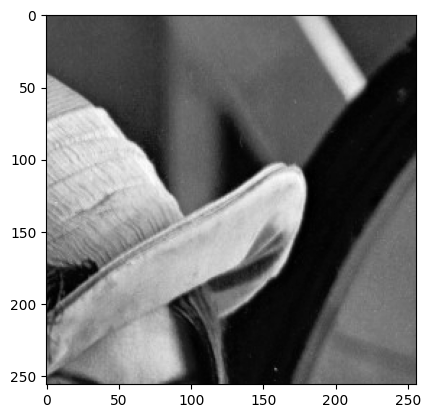

In [8]:
# A compléter
# Récupérez le quart haut droit d'img
qhd = img[:rows//2,cols//2:]

# Affichez le résultat
plt.imshow(qhd,'gray')

---
**3.**

Transposez la variable *img* avec la fonction *transpose* de NumPy, et affichez le résultat en niveaux de gris.

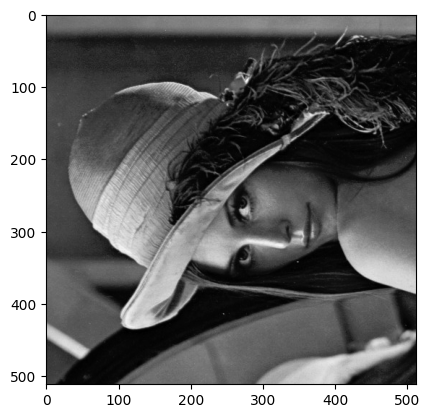

In [9]:
# A compléter
img_t = np.transpose(img)

plt.imshow(img_t,'gray')

Réalisez une rotation de 90° à img avec la fonction *rot90* de NumPy et affichez le résultat obtenu en niveaux de gris.

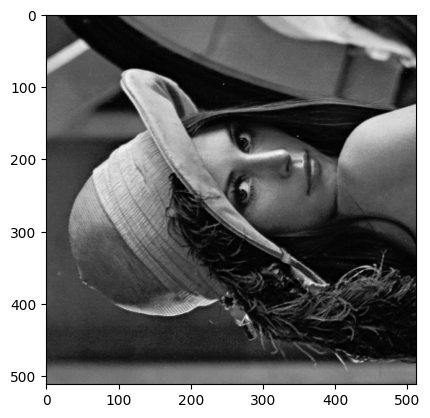

In [10]:
# A compléter
# Rotation de l'image de 90° et affichage du résultat

img_90 = np.rot90(img)

plt.imshow(img_90,'gray')

Que remarquez-vous ?

**_REPONSE :_** The transpose function does not work exactly like a 90° rotation, because it also swiched the order of the axes, making the woman face the other way.

La fonction précédente *rot90* fait le job, mais uniquement pour des rotations à 90, 180 ou 270°. Si on veut effectuer une rotation à n'importe quel degré, il faut utiliser une autre fonction.

D'un point de vue plus global, pour effectuer sur une image une rotation, une translation, ou les 2, il faut de préférence passer par une matrice de transformation géométrique, qu'on appliquera sur l'image. La transformation géométrique sera abordée dans le cours de Stéréovision (Semestre 4.2).

Réalisez une rotation de 45° à *img* avec les fonctions d'OpenCV :
- *getRotationMatrix2D* pour obtenir la matrice de rotation de 45° pour l'image *img* ;
- *warpAffine* pour appliquer la rotation à *img* avec la matrice de rotation calculée.

Affichez le résultat obtenu en niveaux de gris.

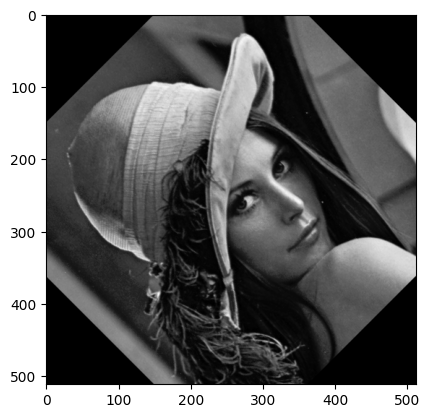

In [11]:
# A compléter
# Calcul de la matrice de rotation
center = (cols/2, rows/2)
rotate_matrix = cv2.getRotationMatrix2D(center=center, angle=45, scale=1)

# Rotation de l'image avec la matrice de rotation et affichage du résultat
img_r = cv2.warpAffine(
    src=img, M=rotate_matrix, dsize=(cols, rows))

plt.imshow(img_r,'gray')

Que remarquez-vous ?

**_REPONSE :_** The rotated image still needs to fit into a 512x512 matrix, because of that regios of zeros are created and the image edges are lost.

---
## Ex 3. Création et visualisation des images

**1.**

Créez une matrice *_M_* de taille *_N x N_* avec *N = 256* dont le terme général est **_M_** *(i,j) = j*, puis affichez la en niveaux de gris.



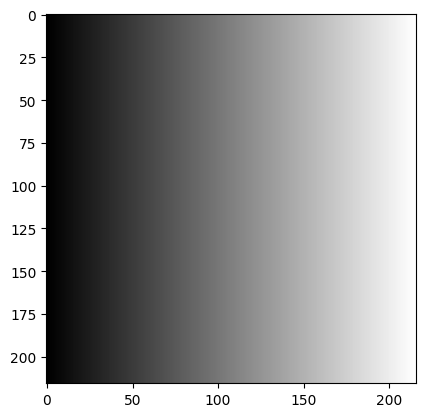

In [13]:
# A compléter
# Création de la matrice M
N = 216
M = np.zeros((N,N))
for j in range(N):
    M[:,j] = j

# Affichage de la matrice M en niveaux de gris
plt.imshow(M,'gray')

---
**2.**

Pour l'instant, nous avons uniquement affiché nos images en niveaux de gris (*'gray'*), mais il est possible d'utiliser des palettes différentes. 

La liste des palettes disponibles sur Matplotlib est à ce lien : https://matplotlib.org/2.0.2/examples/color/colormaps_reference.html.

Affichez la matrice M avec une palette de couleurs (autre que niveaux de gris)

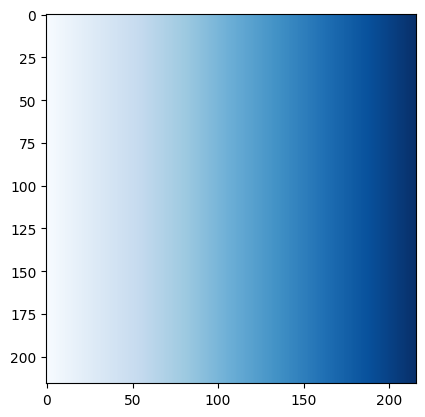

In [14]:
# A compléter
# Affichage de la palette de couleurs
plt.imshow(M,'Blues')

---
**3. (optionnel)**

Il est également possible de créer sa propre palette et de l'appliquer sur une image.

Pour cela, on va créer une instance *colormap* de la classe *ListedColormap*, qui contiendra la matrice *colors*. Cette matrice sera de taille *(N,4)*, où N est un naturel de votre choix. Les 3 premières colonnes (RGB) contiendront des réels entre 0 et 1, et la dernière colonne (A pour la transparence) sera un vecteur rempli de 1, de longueur *N*.

Créez la matrice *colors*.

In [24]:

colors = np.zeros((N,4))
colors.shape[1]

4

In [37]:
# A compléter
N = 3
colors = np.zeros((N,4))
for i in range(colors.shape[1]):
    colors[:,3-i] = 1/(i+1)
    
for i in range(N):
    colors[i,:-1] = colors[i,:-1] + i*0.10
    
print(colors)
# Vérification de la taille de la matrice colors
assert colors.shape == (N,4), 'la taille de la matrice doit être (N, 4), N = '+str(N)+' , colors.shape = '+str(colors.shape)

[[0.25       0.33333333 0.5        1.        ]
 [0.35       0.43333333 0.6        1.        ]
 [0.45       0.53333333 0.7        1.        ]]


In [38]:
# Création de la colormap
from matplotlib.colors import ListedColormap
colormap = ListedColormap(colors)
print(colormap)

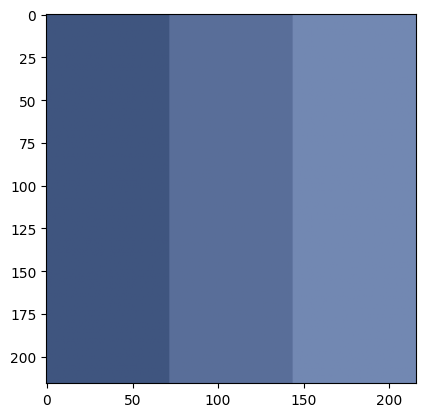

In [39]:
# A compléter
# Affichage de la matrice M avec la palette créée
plt.imshow(M,colormap)

--- 
## Ex. 4 : Calculs sur les images ###

Pour cette partie, passons à la couleur en étudiant l'image lena_color.tif. 

**1.**

Commencez d'abord par la charger et stockez la dans la variable img_color. 

In [56]:
# A compléter
# Chargement de l'image lena_color.tif
img_color = cv2.imread(path_base+'lena_color.tif',-1) 

Affichez le nombre de dimensions de l'image chargée.

In [49]:
# A compléter
# Affichage du nombre de dimensions de l'image chargée
rows,cols,channels = img_color2.shape
img_dtype = img_color2.dtype
print(rows, cols, channels)
print(img_dtype)

512 512 3
uint8


---
**2.**

Affichez les dimensions de l'image.

In [50]:
# A compléter
# Affichage des dimensions de l'image
print(rows, cols, channels)

512 512 3


Vous pouvez voir que l'image couleur chargée possède 3 channels : un channel bleu, un channel vert et un channel rouge. Le format de l'image est BGR (Blue, Green, Red). Affichez les composantes bleue, verte et rouge de l'image (images des intensités de chaque channel en N&B).

In [53]:
print(img_color[:,:,0])

[[125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 [125 125 133 ... 122 110  90]
 ...
 [ 60  60  58 ...  84  76  79]
 [ 57  57  62 ...  79  81  81]
 [ 57  57  62 ...  79  81  81]]


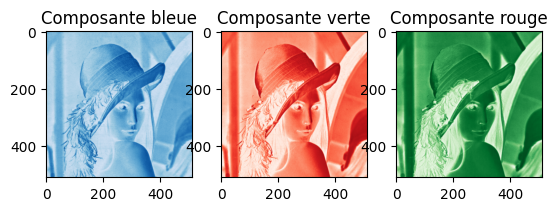

In [55]:
# A compléter
# Affichage de chaque composante couleur (en N&B)
plt.subplot(1,3,1)
plt.imshow(img_color[:,:,0],'Blues')
plt.title("Composante bleue")
plt.subplot(1,3,2)
plt.imshow(img_color[:,:,1],'Reds')
plt.title("Composante verte")
plt.subplot(1,3,3)
plt.imshow(img_color[:,:,2],'Greens')
plt.title("Composante rouge")
plt.show()

Affichez l'image img_color en couleur.

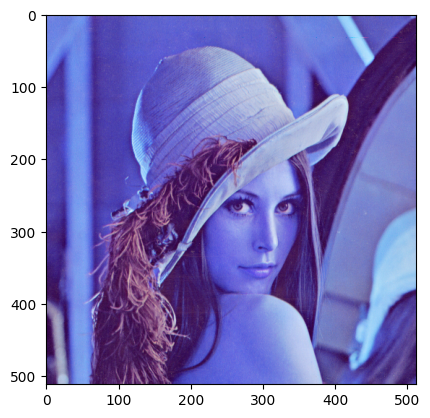

In [58]:
# A compléter
# Affichage de img_color en couleur
plt.imshow(img_color)

L'image est bizarre ? Vous remarquez un soucis particulier ? Au niveau des couleurs ? C'est normal : La palette par défaut de Matplotlib est BGR (Blue, Green, Red), et non RGB.

Pour des raisons pratiques, convertissez l'image BGR en format RGB avec la fonction cv2.cvtColor avec cv2.COLOR_BGR2RB en paramètre :

        img_rgb = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)

In [60]:
# A compléter
# Conversion de l'image de BGR en RGB
img_color2 = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

Affichez l'image RGB.

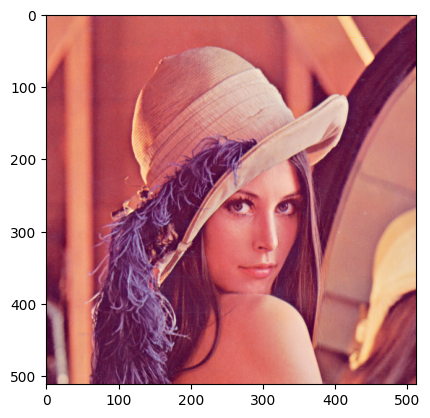

In [61]:
# A compléter
# Affichage de img_color en couleur
plt.imshow(img_color2)

---
**3.**

Convertissez l'image couleur RGB *img_color_rgb* en niveaux de gris :
- En utilisant la fonction cvtColor d'OpenCV
- En la calculant manuellement avec la formule *$I_{gray}$ = $\alpha$R + $\beta$G + $\gamma$B* sachant que *$\alpha$ = 0.2989*, *$\beta$ = 0.5870* et *$\gamma$ = 0.1140* 

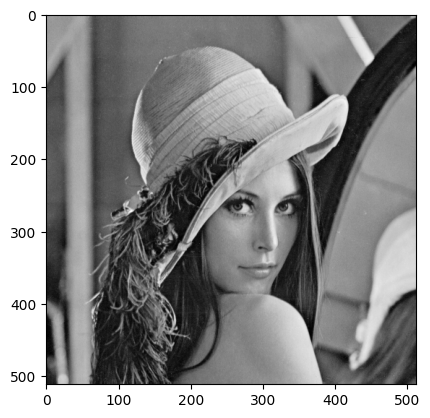

In [65]:
# A compléter
# Conversion en niveaux de gris avec cvtColor
img_g = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
# Affichage de l'image en niveaux de gris
plt.imshow(img_g, cmap='gray')

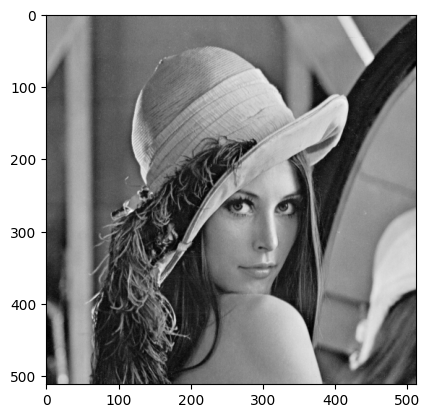

In [68]:
# A compléter
alpha = 0.2989
beta = 0.5870
gamma = 0.1140

# Conversion manuelle en niveaux de gris
img_g2 = alpha*img_color[:,:,2] + beta*img_color[:,:,1] + gamma*img_color[:,:,0]
# Affichage de l'image en niveaux de gris
plt.imshow(img_g2, cmap='gray')

Comparez les résultats :
- Au niveau des matrices elles-mêmes ;
- Au niveau visuel

In [70]:
from skimage.metrics import mean_squared_error
mean_squared_error(img_g, img_g2)

0.08385502867595686

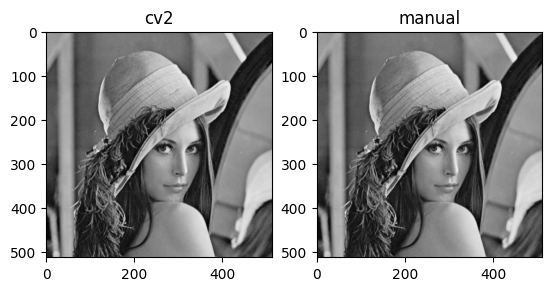

In [71]:
plt.subplot(1,2,1)
plt.imshow(img_g, cmap='gray')
plt.title("cv2")
plt.subplot(1,2,2)
plt.imshow(img_g2, cmap='gray')
plt.title("manual")
plt.show()

**_REPONSE :_** The two images have a very small difference numerically, only an MSE of 0.08 between them. This correspond to the visual level, where I cannot particularly notice any difference.

---
## Ex. 5 : Quantification

**1.**

Pour cette partie, nous allons réutiliser l'image lena_gray.tif. Chargez cette dernière.

In [72]:
# A compléter
# Chargement de l'image lena_gray en niveau de gris
img = cv2.imread(path_base+'lena_gray.tif',-1) 

Dans l'objectif de pouvoir compresser l'image, nous allons réduire le nombre de niveaux de gris grâce à une quantification.

Ici, vous ferez une quantification scalaire uniforme : à partir d'une image contenant K niveaux de gris, vous réduirez ce nombre à N niveaux de gris.

Dans notre cas, la quantification est scalaire (donc notre dictionnaire sera composé de scalaires, à savoir les niveaux de gris retenus), et uniforme. Cela veut dire que le pas de quantification (intervalle entre 2 niveaux de gris retenu) est constant. Il faudra donc calculer le pas de quantification en fonction de votre image et de N (nombre de niveaux de gris voulus).

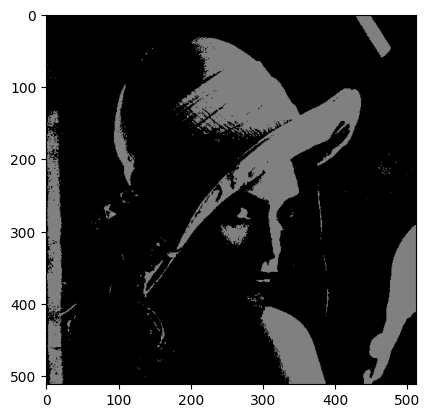

In [85]:
# A compléter
# Fonction imquantize
def imquantize(img,N):
    gmax = np.max(img)
    gmin = np.min(img)
    step = (gmax-gmin)//N
    # print(gmax)
    # print(gmin)
    # print(step)
    
    img_q = np.zeros(img.shape)
    
    # for i in range(gmin, gmax, step):
    #     img_q
        
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            img_q[i,j] = img[i,j]//step * step
            
    # print(img_q)
            
    return img_q

img_q = imquantize(img,2)
plt.imshow(img_q, cmap='gray')

On désire déterminer l'influence d'une quantification à pas variables.

Appliquez la quantification de l'image *lena_gray* pour ne garder 128, 64, 32, 16, 8, 4 et 2 niveaux de gris.

In [ ]:
# A compléter
# Pas de quantification stockés dans une liste
steps = [2, 4, 8, 16, 32, 64, 128]
# Construction de la liste des images quantifiées correspondantes à chaque pas de quantification 
...

Affichez les images quantifiées correspondantes à chaque pas de quantification afin de déterminer le seuil minimal de quantification à partir duquel certains faux contours apparaissent.

In [ ]:
# A compléter
# Affichage de l'image originale et des images quantifiées
...

On va maintenant créer un histogramme d'une image. C'est un graphique qui affiche la distribution des valeurs de l'image. C'est un outil très utilisé dans ce domaine, donc la base, c'est de bien construire un histogramme. Un histogramme bien construit, c'est un histogramme avec :
- En abscisse : les valeurs possibles que peuvent prendre un pixel de l'image (même si elles ne sont pas présentes réellement dans l'image)
- En ordonnée : le nombre de pixels de l'image égaux à la valeur d'abscisse. La somme de toutes les valeurs en ordonnées nous donne le nombre de pixels de l'image.

Implémentez une fonction qui, à partir d'une image, affiche son histogramme en niveaux de gris.

In [ ]:
# A compléter
# Fonction de création d'histogrammes des niveaux de gris d'une image
def hist(img):
    ...

Affichez l'histogramme de l'image originale et des images quantifiées grâce à la fonction hist de Matplotlib.

In [ ]:
# A compléter
# Affichage des histogrammes de l'image originale et des images quantifiées
...

---
**2.**

Passons maintenant à l'image couleur *cameleon.tif*

Commencez par charger l'image en niveaux de gris et affichez-la.

In [ ]:
# A compléter
# Chargement de l'image cameleon en niveaux de gris
...
# Affichage de l'image
...

Appliquez la quantification de l'image *cameleon* pour ne garder que 128, 64, 32, 16, 8, 4 et 2 niveaux de gris.

In [ ]:
# A compléter
# Pas de quantification stockés dans une liste
...
# Construction de la liste des images quantifiées correspondantes à chaque pas de quantification 
...

Affichez les images quantifiées correspondantes à chaque pas de quantification afin de déterminer le seuil minimal de quantification à partir duquel certains faux contours apparaissent.

In [ ]:
# A compléter
# Affichage de l'image originale et des images quantifiées
...

Affichez l'histogramme de l'image originale et des images quantifiées grâce à la fonction hist de Matplotlib.

In [ ]:
# A compléter
# Affichage des histogrammes de l'image originale et des images quantifiées
...

Comparez les résultats obtenus avec les 2 images et conclure.

**_REPONSE :_**

---
**3.**

La quantification peut se faire également pour les images en couleur. Pour cela, nous allons charger l'image *lena_color*.

In [ ]:
# A compléter
# Chargement de l'image lena_color
...

Comme vous le savez déjà, une image couleur possède 3 canaux presque-indépendants les uns des autres. On peut quantifier l'image en utilisant la même fonction développée précédemment sur chacun des canaux. Faites un essai de cette méthode sur chacun des canaux de *lena_color*, de la même manière que précedemment, en ne gardant que 4 niveaux de gris et affichez le résultat.

In [ ]:
# A compléter
# Quantification de chacun des channels pour ne garder que 4 niveaux de gris
...
# Affichage de l'image quantifiée
...

Que remarquez-vous ?

**_REPONSE :_**

Pour effectuer une quantification couleur, il nous faut un autre algorithme, pour définir les N couleurs les plus représentatives de notre image.

Comme on est gentil :D , on vous passe la fonction imquantize (équivalent de la fonction Matlab).
imquantize prend en entrée :
- img : l'image à quantifier ;
- n_colors : le nombre de couleurs maximum pour la quantification.

imquantize retourne en sortie quant, l'image img quantifiée.

Ici la quantification se fait en sélectionnant les *N* couleurs les plus représentatives de notre image.

In [ ]:
def imcolorquantize(img,n_colors):
    if img.ndim == 2:
        img = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
    (h, w) = img.shape[:2]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    img = img.reshape((img.shape[0] * img.shape[1], 3))
    
    # apply k-means using the specified number of clusters and
    # then create the quantized image based on the predictions
    clt = MiniBatchKMeans(n_colors)
    labels = clt.fit_predict(img)
    quant = clt.cluster_centers_.astype("uint8")[labels]
     
    # reshape the feature vectors to images
    quant = quant.reshape((h, w, 3))
 
    # convert from L*a*b* to RGB
    quant = cv2.cvtColor(quant, cv2.COLOR_LAB2RGB)

    return quant

La fonction implémentée, appliquez une quantification à l'image *lena_color* pour ne retenir que 4 couleurs et affichez-la.

In [ ]:
# A compléter
# Application de la quantification
...
# Affichage du résultat obtenu
...

## Ex 6. : Re-échantillonnage

**1.**

Chargez l'image *mire.png* en niveaux de gris et affichez-la.

In [ ]:
# A compléter
# Chargement de l'image
...
# Affichage de l'image
...

Créez une version sous-échantillonnée par un facteur 2 de cette image à l'aide d'une fonction que vous écrirez. Pour cela, créez une nouvelle image en ne prenant qu'un pixel sur deux dans l'image originale. (Opération à réaliser sur les lignes et les colonnes de l'image de départ).

In [ ]:
# A compléter
# Fonction de sous-échantillonage
def subsampling(img,factor):
    ...

In [ ]:
# A compléter
# Affichage de l'image sous échantillonnée avec un facteur 2
...

---
**2.**

Créez la même fonction sans boucle grâce à l'indexation des tableaux NumPy.

In [ ]:
# A compléter
# Fonction de sous échantillonage sans boucle
def subsampling2(img,factor):
    ...

In [ ]:
# A compléter
# Affichage de l'image sous échantillonnée avec un facteur 2
...

Décrivez les effets du sous-échantillonnage.

**_REPONSE :_**

---
**3.**

Refaites le sous-échantillonnage de la même image mais avec un facteur 4 (avec les 2 fonctions que vous avez implémenté).

In [ ]:
# A compléter
# Affichage de l'image sous échantillonnée avec un facteur 4 (fonction avec boucle)
...

In [ ]:
# A compléter
# Affichage de l'image sous échantillonnée avec un facteur 4 (fonction sans boucle)
...

Décrivez les effets du sous-échantillonnage.

**_REPONSE :_**

## Rendu de TP
Le rendu qui vous est demandé pour les TP de TIM est la version HTML de ce notebook. Pour l'obtenir: Fichier, télécharger au format, HTML (.html).